<a href="https://colab.research.google.com/github/Tolureis/CMPE-403-Fundamentals-of-Image-Processing/blob/main/Intensity_Spatial_Filtering_Convolution_and_Edge_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intensity Transformations and Spatial Filtering

This notebook demonstrates common **intensity transformations** and **spatial filtering** techniques using Python and OpenCV.  Intensity transformations operate on pixel values to improve the appearance of an image or prepare it for further processing.  Spatial filtering uses convolution kernels to blur, sharpen or detect edges in an image.  All examples below read an image from disk rather than embedding it in the notebook.  Replace `image_path` in the code with the path to your image file.

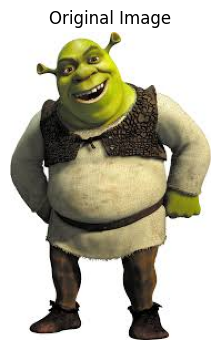

In [3]:
# Install dependencies if necessary
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read an image from disk.  Replace this path with your own image file.
image_path = '/content/shrek.jpg'  # change to your image file path
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f'Cannot read image at {image_path}')

# Convert BGR (OpenCV) to RGB for matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display original image
plt.figure(figsize=(4,4))
plt.title('Original Image')
plt.imshow(image_rgb)
plt.axis('off')
plt.show()


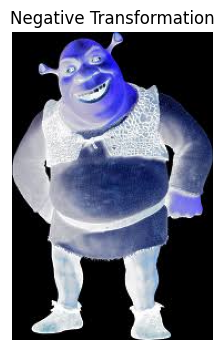

In [4]:
# 1.1 Image negative
negative = 255 - image
negative_rgb = cv2.cvtColor(negative, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.title('Negative Transformation')
plt.imshow(negative_rgb)
plt.axis('off')
plt.show()


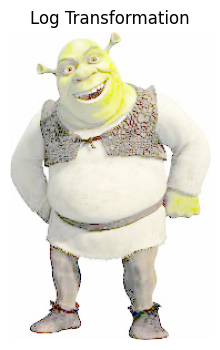

In [14]:
# 1.2 Log transformation
# Convert to float to avoid overflow during calculation
img_float = image.astype(np.float64)

# Calculate c based on the maximum value in the image
# Add a small epsilon (1e-5) to avoid divide by zero if max is 0
max_val = np.max(img_float)
c_log = 255 / (np.log(1 + max_val) + 1e-5)

# Apply log transform: s = c * log(1 + r)
log_transformed = c_log * np.log(1 + img_float)

# Convert back to uint8
log_transformed = np.uint8(np.clip(log_transformed, 0, 255))
log_rgb = cv2.cvtColor(log_transformed, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.title('Log Transformation')
plt.imshow(log_rgb)
plt.axis('off')
plt.show()

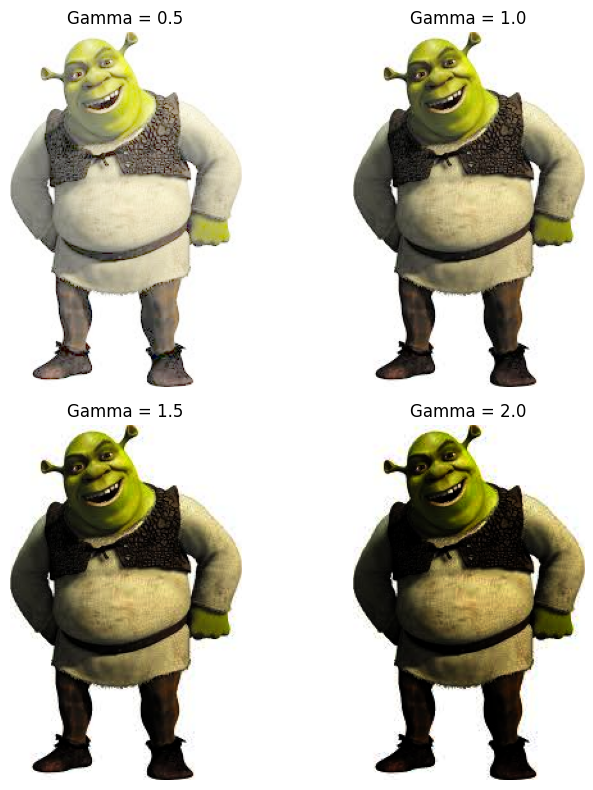

In [6]:
# 1.3 Gamma transformation
# Try a few gamma values to observe the effect on brightness
gamma_values = [0.5, 1.0, 1.5, 2.0]
plt.figure(figsize=(8, 8))
for i, gamma in enumerate(gamma_values):
    gamma_corrected = np.array(255 * ((image / 255) ** gamma), dtype='uint8')
    gamma_rgb = cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i+1)
    plt.title(f'Gamma = {gamma}')
    plt.imshow(gamma_rgb)
    plt.axis('off')

plt.tight_layout()
plt.show()


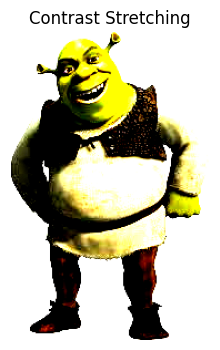

In [7]:
# 1.4 Contrast stretching (piecewise linear transformation)
def contrast_stretch(img, r1, s1, r2, s2):
    def pixel_val(pix):
        if 0 <= pix <= r1:
            return (s1 / r1) * pix
        elif r1 < pix <= r2:
            return ((s2 - s1) / (r2 - r1)) * (pix - r1) + s1
        else:
            return ((255 - s2) / (255 - r2)) * (pix - r2) + s2

    pixel_vec = np.vectorize(pixel_val)
    return pixel_vec(img).astype(np.uint8)

# Choose parameters for contrast stretching
r1, s1 = 70, 0
r2, s2 = 140, 255

contrast_img = contrast_stretch(image, r1, s1, r2, s2)
contrast_rgb = cv2.cvtColor(contrast_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.title('Contrast Stretching')
plt.imshow(contrast_rgb)
plt.axis('off')
plt.show()


## 2. Spatial filtering and convolution

Spatial filtering modifies pixel values based on their neighbors by convolving the image with a kernel.  The process of convolution slides a small matrix (kernel) across the image and computes a weighted sum at each location.  Spatial filters are used for several purposes:

* **Smoothing (blurring):** Averages neighboring pixels to reduce noise and high‑frequency detail.
* **Sharpening:** Highlights edges by emphasizing intensity transitions; a sharpening kernel preserves the center pixel with a positive weight and subtracts the neighbors with negative weights.
* **Edge detection:** Identifies object boundaries by locating pixels where intensity changes rapidly.  Edge detection kernels such as Sobel and Laplacian compute derivatives of the image intensity.

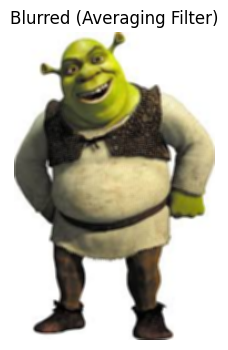

In [8]:
# 2.1 Smoothing with an averaging kernel
# Define a 3x3 averaging kernel
kernel_blur = np.ones((3,3), np.float32) / 9
blurred = cv2.filter2D(image, -1, kernel_blur)
blurred_rgb = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.title('Blurred (Averaging Filter)')
plt.imshow(blurred_rgb)
plt.axis('off')
plt.show()


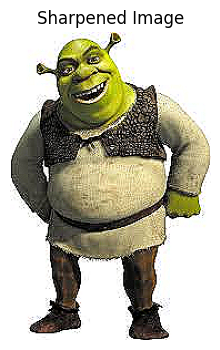

In [9]:
# 2.2 Sharpening filter
# Define a sharpening kernel
kernel_sharpen = np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]], dtype=np.float32)
sharpened = cv2.filter2D(image, -1, kernel_sharpen)
sharpened_rgb = cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.title('Sharpened Image')
plt.imshow(sharpened_rgb)
plt.axis('off')
plt.show()


## 3. Edge detection

Edges correspond to places where the image intensity changes abruptly.  Detecting edges is essential for object recognition, segmentation and tracking.  Converting the image to grayscale simplifies the process.  We demonstrate three widely used operators: **Sobel**, **Laplacian** and **Canny**.

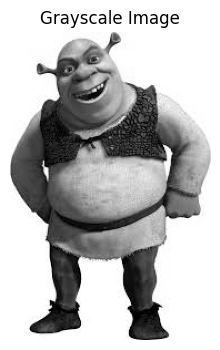

In [10]:
# Convert the original image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(4,4))
plt.title('Grayscale Image')
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()


### 3.1 Sobel operator

The Sobel operator computes discrete derivatives of the image to highlight regions with high intensity gradients.  It uses two kernels (G_x and G_y) to detect horizontal and vertical changes.  After computing the gradient components, the overall gradient magnitude is obtained by combining them.

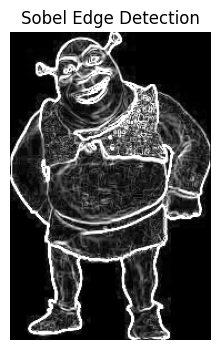

In [11]:
# Apply Sobel operator
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)  # horizontal edges
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)  # vertical edges
gradient_magnitude = cv2.magnitude(sobelx, sobely)
# Convert result to uint8 for display
gradient_magnitude = cv2.convertScaleAbs(gradient_magnitude)

plt.figure(figsize=(4,4))
plt.title('Sobel Edge Detection')
plt.imshow(gradient_magnitude, cmap='gray')
plt.axis('off')
plt.show()


### 3.2 Laplacian operator

The Laplacian operator computes a second‑order spatial derivative.  Unlike Sobel, it is isotropic and therefore detects edges in all directions.  The Laplacian highlights regions where the intensity changes rapidly but produces signed values that must be converted to an absolute scale for visualization.

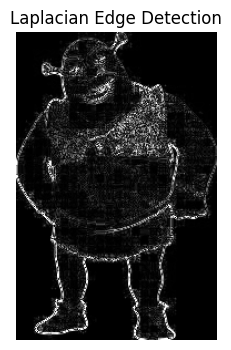

In [12]:
# Apply Laplacian operator
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian_abs = cv2.convertScaleAbs(laplacian)

plt.figure(figsize=(4,4))
plt.title('Laplacian Edge Detection')
plt.imshow(laplacian_abs, cmap='gray')
plt.axis('off')
plt.show()


### 3.3 Canny edge detector

The Canny edge detector is a multi‑stage algorithm designed to produce thin and connected edges.  Its pipeline includes: noise reduction using Gaussian blur, gradient calculation with Sobel kernels, non‑maximum suppression to thin edges and hysteresis thresholding to link edges.  Canny is widely used because it is robust and yields clean edge maps.

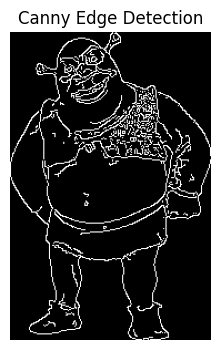

In [13]:
# Apply Canny edge detector
# The thresholds can be tuned depending on the image.  Lower threshold=100, higher threshold=200 are common defaults.
canny_edges = cv2.Canny(gray, threshold1=100, threshold2=200)

plt.figure(figsize=(4,4))
plt.title('Canny Edge Detection')
plt.imshow(canny_edges, cmap='gray')
plt.axis('off')
plt.show()
